In [13]:
import sys
sys.path.append("/home/export/sdurgut/scratch/alps/tracking_ALPs/")
sys.path.append('/home/export/sdurgut/scratch/alps/bkg/FORESEE/alp')
sys.path.append('/home/export/sdurgut/scratch/alps/bkg/FORESEE')
src_path = "../"
sys.path.append(src_path)
import numpy as np
from analysis.module_VBF import TRT_length, read_data, raw_to_events
import numpy as np
import math
import matplotlib.pyplot as plt
from src.foresee import Foresee, Utility, Model
import pandas as pd
from scripts.plotting.param_space_plotting_utils import calculate_n2g
from scripts.analysis_helpers.file_helpers import ma_to_name
import sys
from pathlib import Path
PROJECT_ROOT = Path('/home/export/sdurgut/scratch/alps/tracking_ALPs')
sys.path.insert(0, str(PROJECT_ROOT / 'analysis'))
sys.path.insert(0, str(PROJECT_ROOT))


In [14]:
def load_events(gagg_list, ma, era='run3'):

    ma_name = ma_to_name(ma)
    raw_events = read_data(
        ma_name,
        num=100000,                              # max events to load
        data_dir=str(PROJECT_ROOT / 'data/cmsrun3-csvs'),
    )
    events = raw_to_events(raw_events, gaggs=gagg_list, ma=ma, era=era)
    print(f'Loaded {len(events)} events')
    return events

In [15]:
#apply VBF cuts to events 
def apply_vbf_cuts(events):
    from scripts.analysis_helpers.kinematics_helpers import compute_mjj
    """Apply VBF cuts to events."""
    events_vbf = []
    leading_jet_pt_cut = 105.0
    sub_jet_pt_cut = 40.0
    mjj_cut = 720.0
    deta_cut = 3.0
    for ev in events:
        lead_jet_pt = max(ev['j1']['pt'], ev['j2']['pt'])
        sub_jet_pt = min(ev['j1']['pt'], ev['j2']['pt'])
        mjj = compute_mjj(ev)
        passes_lead_jet_pt = lead_jet_pt > leading_jet_pt_cut
        passes_sub_jet_pt = sub_jet_pt > sub_jet_pt_cut
        passes_mjj = mjj > mjj_cut
        passes_deta = abs(ev['j1']['eta'] - ev['j2']['eta']) > deta_cut
        if not (passes_lead_jet_pt & passes_sub_jet_pt & passes_mjj & passes_deta):
            continue
        events_vbf.append(ev)
    print('before cuts:', len(events))
    print('after cuts:', len(events_vbf))
    acc = len(events_vbf)/len(events)
    print('acceptance:', acc)
    return events_vbf, acc

In [16]:
alp_0p01 = load_events([1e-4], 0.01)
alp_0p10 = load_events([1e-4], 0.10)
alp_1p00 = load_events([1e-4], 1.00)
alp_10p00 = load_events([1e-4], 10.00)



Loaded 40000 events
Loaded 40000 events
Loaded 40000 events
Loaded 40000 events


In [17]:
alp_pt_0p01 = [ev['a']['pt'] for ev in alp_0p01]
alp_pt_0p10 = [ev['a']['pt'] for ev in alp_0p10]
alp_pt_1p00 = [ev['a']['pt'] for ev in alp_1p00]
alp_pt_10p00 = [ev['a']['pt'] for ev in alp_10p00]


Text(0.5, 1.0, 'ALP $p_T$ distribution, fixed $g_{a\\gamma\\gamma}=0.1\\,$TeV$^{-1}$')

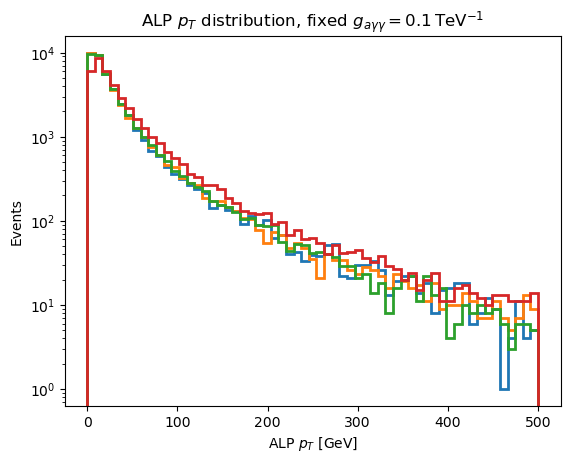

In [18]:
#plot the pt distribution of the ALPs and overlay them
plt.hist(alp_pt_0p01, bins=np.linspace(0, 500, 60), histtype="step", lw=2, label=fr"$m_a$ = 0.01 GeV")
plt.hist(alp_pt_0p10, bins=np.linspace(0, 500, 60), histtype="step", lw=2, label=fr"$m_a$ = 0.10 GeV")
plt.hist(alp_pt_1p00, bins=np.linspace(0, 500, 60), histtype="step", lw=2, label=fr"$m_a$ = 1.00 GeV")
plt.hist(alp_pt_10p00, bins=np.linspace(0, 500, 60), histtype="step", lw=2, label=fr"$m_a$ = 10.00 GeV")
plt.xlabel(r"ALP $p_T$ [GeV]")
plt.ylabel("Events")
plt.yscale("log")
plt.title(fr"ALP $p_T$ distribution, fixed $g_{{a\gamma\gamma}}=0.1\,$TeV$^{{-1}}$")

In [19]:
#apply vbf cuts to the events
events_0p01_vbf, acc_0p01 = apply_vbf_cuts(alp_0p01)
events_0p10_vbf, acc_0p10 = apply_vbf_cuts(alp_0p10)
events_1p00_vbf, acc_1p00 = apply_vbf_cuts(alp_1p00)
events_10p00_vbf, acc_10p00 = apply_vbf_cuts(alp_10p00)


before cuts: 40000
after cuts: 488
acceptance: 0.0122
before cuts: 40000
after cuts: 492
acceptance: 0.0123
before cuts: 40000
after cuts: 477
acceptance: 0.011925
before cuts: 40000
after cuts: 648
acceptance: 0.0162


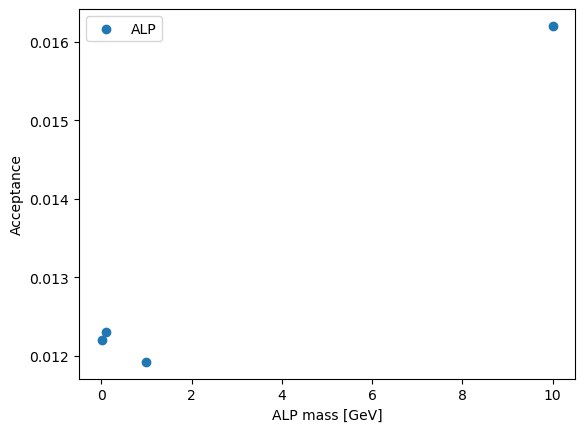

In [20]:
# plot mass vs acceptance
m_a = [0.01, 0.10, 1.00, 10.00]
acc = [acc_0p01, acc_0p10, acc_1p00, acc_10p00]
plt.scatter(m_a, acc, label="ALP")
plt.xlabel(r"ALP mass [GeV]")
plt.ylabel("Acceptance")
plt.legend()
plt.show()


In [21]:
alp_pt_0p01_vbf = [ev['a']['pt'] for ev in events_0p01_vbf]
alp_pt_0p10_vbf = [ev['a']['pt'] for ev in events_0p10_vbf]
alp_pt_1p00_vbf = [ev['a']['pt'] for ev in events_1p00_vbf]
alp_pt_10p00_vbf = [ev['a']['pt'] for ev in events_10p00_vbf]

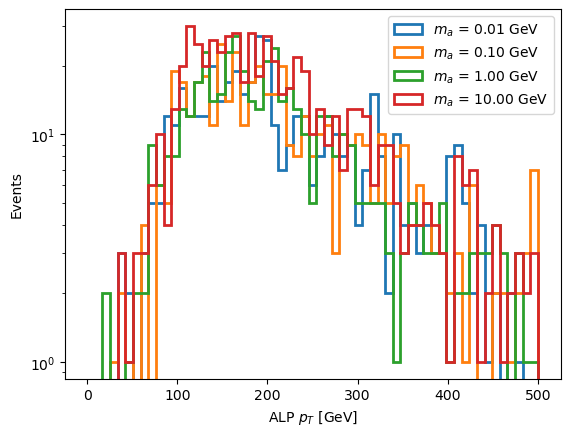

In [22]:
#plot pt distribution of the ALPs after vbf cuts
plt.hist(alp_pt_0p01_vbf, bins=np.linspace(0, 500, 60), histtype="step", lw=2, label=fr"$m_a$ = 0.01 GeV")
plt.hist(alp_pt_0p10_vbf, bins=np.linspace(0, 500, 60), histtype="step", lw=2, label=fr"$m_a$ = 0.10 GeV")
plt.hist(alp_pt_1p00_vbf, bins=np.linspace(0, 500, 60), histtype="step", lw=2, label=fr"$m_a$ = 1.00 GeV")
plt.hist(alp_pt_10p00_vbf, bins=np.linspace(0, 500, 60), histtype="step", lw=2, label=fr"$m_a$ = 10.00 GeV")
plt.xlabel(r"ALP $p_T$ [GeV]")
plt.ylabel("Events")
plt.legend()
plt.yscale("log")
plt.show()


In [23]:
#calculate the total yields of the ALPS before and after vbf cuts at 312 fb^-1 using the cross section for the signal


In [24]:
def alp_xsec_pb(gagg):
    xsec = 180 * (gagg/10**-2)**2 # in pb, gagg in gev-1
    return xsec

In [25]:
def calc_yield(passed_events, gagg, n_total_events = 40000, L = 312,):
    alp_xsec = alp_xsec_pb(gagg)
    yield_nu = (len(passed_events)/n_total_events) * (L*1e3) * alp_xsec
    print(f"yield: {yield_nu:.3e}")
    return yield_nu

In [26]:
#calculate vbf yields at a reference gagg
N_sig_0p01_vbf = calc_yield(events_0p01_vbf, 1e-4)
N_sig_0p10_vbf = calc_yield(events_0p10_vbf, 1e-4)
N_sig_1p00_vbf = calc_yield(events_1p00_vbf, 1e-4)
N_sig_10p00_vbf = calc_yield(events_10p00_vbf, 1e-4)

yield: 6.852e+01
yield: 6.908e+01
yield: 6.697e+01
yield: 9.098e+01


In [27]:
#calculate all yields (before VBF)
N_sig_0p01 = calc_yield(alp_0p01, 1e-4)
N_sig_0p10 = calc_yield(alp_0p10, 1e-4)
N_sig_1p00 = calc_yield(alp_1p00, 1e-4)
N_sig_10p00 = calc_yield(alp_10p00, 1e-4)


yield: 5.616e+03
yield: 5.616e+03
yield: 5.616e+03
yield: 5.616e+03


In [28]:
w_sig_0p01 = np.full(len(alp_pt_0p01), N_sig_0p01/len(alp_pt_0p01))
w_sig_0p10 = np.full(len(alp_pt_0p10), N_sig_0p10/len(alp_pt_0p10))
w_sig_1p00 = np.full(len(alp_pt_1p00), N_sig_1p00/len(alp_pt_1p00))
w_sig_10p00 = np.full(len(alp_pt_10p00), N_sig_10p00/len(alp_pt_10p00))


In [29]:
w_sig_0p01_vbf = np.full(len(alp_pt_0p01_vbf), N_sig_0p01_vbf/len(alp_pt_0p01_vbf))
w_sig_0p10_vbf = np.full(len(alp_pt_0p10_vbf), N_sig_0p10_vbf/len(alp_pt_0p10_vbf))
w_sig_1p00_vbf = np.full(len(alp_pt_1p00_vbf), N_sig_1p00_vbf/len(alp_pt_1p00_vbf))
w_sig_10p00_vbf = np.full(len(alp_pt_10p00_vbf), N_sig_10p00_vbf/len(alp_pt_10p00_vbf))


## Signal vs Background comparison

In [30]:
soft_kl_sample = pd.read_csv('/home/export/sdurgut/scratch/alps/bkg/FORESEE/alp/kl_sample.csv')

ParserError: Error tokenizing data. C error: Calling read(nbytes) on source failed. Try engine='python'.

In [31]:
soft_kl_sample_pt = np.load("soft_kl_sample_pt.npy")

In [32]:
soft_kl_sample_pt

array([0.87244677, 0.74809723, 0.37742351, ..., 0.4056931 , 0.73517457,
       0.43705914], shape=(8119246,))

In [33]:
w_kaon_soft = (78.585e9 / 2_000_000) * (312*1e3) * 5.47e-4         # per kaon row
w_bkg_soft  = np.full(len(soft_kl_sample_pt), w_kaon_soft)

In [34]:
print(f"bkg total = {w_bkg_soft.sum():.3e}")                       # ~5.45e13

bkg total = 5.445e+13


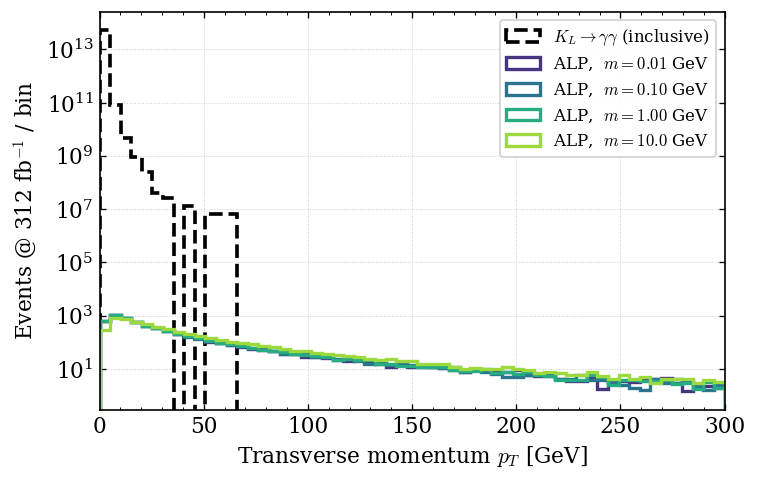

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# ---------- global publication style (same as before) ----------
plt.rcParams.update({
    "font.size": 13,
    "font.family": "serif",
    "mathtext.fontset": "cm",
    "axes.linewidth": 1.0,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.top": True,
    "ytick.right": True,
    "xtick.minor.visible": True,
    "ytick.minor.visible": True,
    "figure.dpi": 120,
    "savefig.dpi": 300,
    "savefig.bbox": "tight",
})

fig, ax = plt.subplots(figsize=(6.5, 4.2))

bins = np.linspace(0, 300, 60)

# background
ax.hist(soft_kl_sample_pt, bins=bins, weights=w_bkg_soft,
        histtype="step", lw=2.2, color="black", ls="--",
        label=r"$K_L \to \gamma\gamma$ (inclusive)")

# signal curves (distinct labels + colormap)
alp_data = [
    (alp_pt_0p01,  w_sig_0p01,  r"ALP,  $m = 0.01$ GeV"),
    (alp_pt_0p10,  w_sig_0p10,  r"ALP,  $m = 0.10$ GeV"),
    (alp_pt_1p00,  w_sig_1p00,  r"ALP,  $m = 1.00$ GeV"),
    (alp_pt_10p00, w_sig_10p00, r"ALP,  $m = 10.0$ GeV"),
]
colors = plt.cm.viridis(np.linspace(0.15, 0.85, len(alp_data)))

for (data, wts, lbl), c in zip(alp_data, colors):
    ax.hist(data, bins=bins, weights=wts,
            histtype="step", lw=2.0, color=c, label=lbl)

ax.set_yscale("log")
ax.set_xlabel(r"Transverse momentum $p_T$ [GeV]")
ax.set_ylabel(r"Events @ 312 fb$^{-1}$ / bin")
ax.set_xlim(bins.min(), bins.max())
ax.grid(True, which="major", ls=":", lw=0.6, alpha=0.6)
ax.legend(fontsize=10, frameon=True, framealpha=0.9)

fig.tight_layout()
fig.savefig("alp_vs_kl_pt.pdf")
plt.show()

### same plot but for VBF 

In [35]:
hard_kl_sample_pt = np.load("hard_kl_sample_pt.npy")


In [36]:
hard_kl_sample_pt

array([1.22192817, 0.78433928, 0.40624591, ..., 4.91249972, 1.05901256,
       0.05245784], shape=(6211275,))

In [37]:
SIGMA_HARD_PB, N_HARD = 3.6413e-3 * 1e9, 20_000_000
w_bkg_hard = np.full(len(hard_kl_sample_pt),
                     (SIGMA_HARD_PB / N_HARD) * (312 * 1e3) * 5.47e-4)
print(f"bkg total = {w_bkg_hard.sum():.3e}")        # check: ~1.93e8

bkg total = 1.930e+08


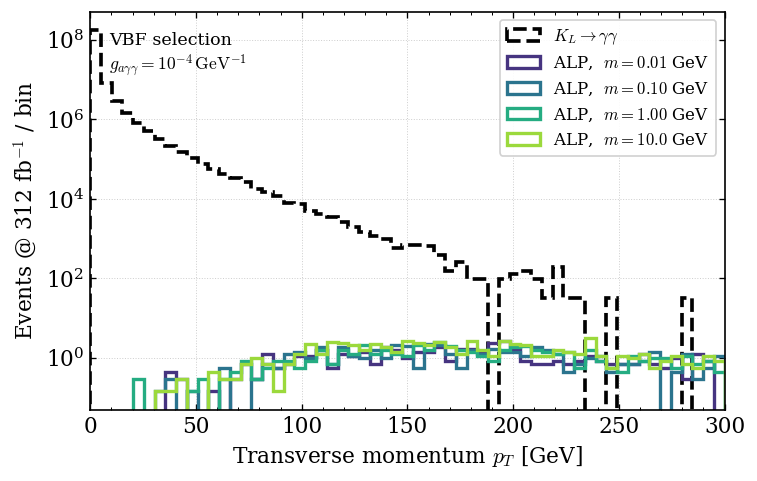

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# ---------- global publication style (same as before) ----------
plt.rcParams.update({
    "font.size": 13,
    "font.family": "serif",
    "mathtext.fontset": "cm",
    "axes.linewidth": 1.0,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.top": True,
    "ytick.right": True,
    "xtick.minor.visible": True,
    "ytick.minor.visible": True,
    "figure.dpi": 120,
    "savefig.dpi": 300,
    "savefig.bbox": "tight",
})

fig, ax = plt.subplots(figsize=(6.5, 4.2))

bins = np.linspace(0, 300, 60)

# background
ax.hist(hard_kl_sample_pt, bins=bins, weights=w_bkg_hard,
        histtype="step", lw=2.2, color="black", ls="--",
        label=r"$K_L \to \gamma\gamma$")

# signal curves (distinct labels + colormap)
alp_data = [
    (alp_pt_0p01_vbf,  w_sig_0p01_vbf,  r"ALP,  $m = 0.01$ GeV"),
    (alp_pt_0p10_vbf,  w_sig_0p10_vbf,  r"ALP,  $m = 0.10$ GeV"),
    (alp_pt_1p00_vbf,  w_sig_1p00_vbf,  r"ALP,  $m = 1.00$ GeV"),
    (alp_pt_10p00_vbf, w_sig_10p00_vbf, r"ALP,  $m = 10.0$ GeV"),
]
colors = plt.cm.viridis(np.linspace(0.15, 0.85, len(alp_data)))

for (data, wts, lbl), c in zip(alp_data, colors):
    ax.hist(data, bins=bins, weights=wts,
            histtype="step", lw=2.0, color=c, label=lbl)

ax.set_yscale("log")
ax.set_xlabel(r"Transverse momentum $p_T$ [GeV]")
ax.set_ylabel(r"Events @ 312 fb$^{-1}$ / bin")
ax.set_xlim(bins.min(), bins.max())
ax.text(0.03, 0.95,
        "VBF selection\n" + r"$g_{a\gamma\gamma}=10^{-4}\,\mathrm{GeV}^{-1}$",
        transform=ax.transAxes, fontsize=10.5, va="top")
ax.grid(True, which="major", ls=":", lw=0.6, alpha=0.6)
ax.legend(fontsize=10, frameon=True, framealpha=0.9)

fig.tight_layout()
fig.savefig("/home/export/sdurgut/scratch/alps/bkg/FORESEE/alp/plots/alp_vs_kl_pt_vbf_312_invfb.png")
plt.show()

## Scouting (3000 fb-1)

In [ ]:
N_sig_0p01_3000_invfb = calc_yield(alp_0p01, 1e-4, L=3000)
N_sig_0p10_3000_invfb = calc_yield(alp_0p10, 1e-4, L=3000)
N_sig_1p00_3000_invfb = calc_yield(alp_1p00, 1e-4, L=3000)
N_sig_10p00_3000_invfb = calc_yield(alp_10p00, 1e-4, L=3000)

yield: 5.400e+04
yield: 5.400e+04
yield: 5.400e+04
yield: 5.400e+04


In [ ]:
w_sig_0p01_3000_invfb = np.full(len(alp_pt_0p01), N_sig_0p01_3000_invfb/len(alp_pt_0p01))
w_sig_0p10_3000_invfb = np.full(len(alp_pt_0p10), N_sig_0p10_3000_invfb/len(alp_pt_0p10))
w_sig_1p00_3000_invfb = np.full(len(alp_pt_1p00), N_sig_1p00_3000_invfb/len(alp_pt_1p00))
w_sig_10p00_3000_invfb = np.full(len(alp_pt_10p00), N_sig_10p00_3000_invfb/len(alp_pt_10p00))

In [ ]:
w_kaon_soft_3000_invfb = (78.585e9 / 2_000_000) * (3000*1e3) * 5.47e-4         # per kaon row
w_bkg_soft_3000_invfb  = np.full(len(soft_kl_sample_pt), w_kaon_soft_3000_invfb)

In [ ]:
print(f"bkg total = {w_bkg_soft_3000_invfb.sum():.3e}")                       # ~5.45e13

bkg total = 5.235e+14


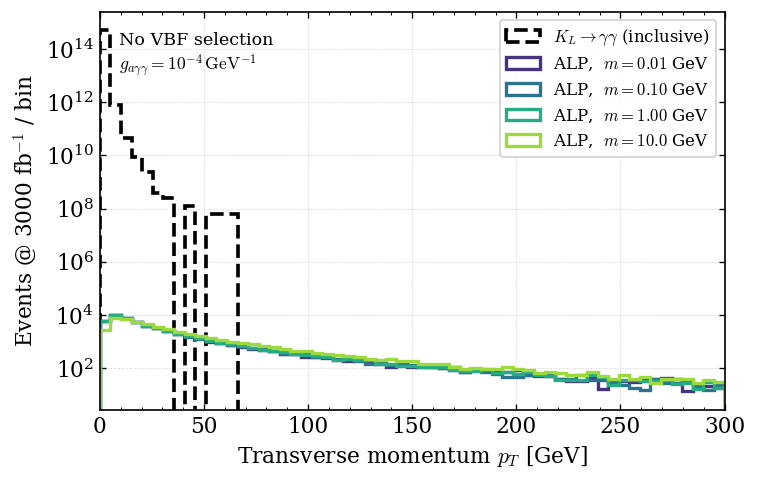

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# ---------- global publication style (same as before) ----------
plt.rcParams.update({
    "font.size": 13,
    "font.family": "serif",
    "mathtext.fontset": "cm",
    "axes.linewidth": 1.0,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.top": True,
    "ytick.right": True,
    "xtick.minor.visible": True,
    "ytick.minor.visible": True,
    "figure.dpi": 120,
    "savefig.dpi": 300,
    "savefig.bbox": "tight",
})

fig, ax = plt.subplots(figsize=(6.5, 4.2))

bins = np.linspace(0, 300, 60)

# background
ax.hist(soft_kl_sample_pt, bins=bins, weights=w_bkg_soft_3000_invfb,
        histtype="step", lw=2.2, color="black", ls="--",
        label=r"$K_L \to \gamma\gamma$ (inclusive)")

# signal curves (distinct labels + colormap)
alp_data = [
    (alp_pt_0p01,  w_sig_0p01_3000_invfb,  r"ALP,  $m = 0.01$ GeV"),
    (alp_pt_0p10,  w_sig_0p10_3000_invfb,  r"ALP,  $m = 0.10$ GeV"),
    (alp_pt_1p00,  w_sig_1p00_3000_invfb,  r"ALP,  $m = 1.00$ GeV"),
    (alp_pt_10p00, w_sig_10p00_3000_invfb, r"ALP,  $m = 10.0$ GeV"),
]
colors = plt.cm.viridis(np.linspace(0.15, 0.85, len(alp_data)))

for (data, wts, lbl), c in zip(alp_data, colors):
    ax.hist(data, bins=bins, weights=wts,
            histtype="step", lw=2.0, color=c, label=lbl)

ax.set_yscale("log")
ax.set_xlabel(r"Transverse momentum $p_T$ [GeV]")
ax.set_ylabel(r"Events @ 3000 fb$^{-1}$ / bin")
ax.set_xlim(bins.min(), bins.max())
ax.text(0.03, 0.95,
        "No VBF selection\n" + r"$g_{a\gamma\gamma}=10^{-4}\,\mathrm{GeV}^{-1}$",
        transform=ax.transAxes, fontsize=10.5, va="top")
ax.grid(True, which="major", ls=":", lw=0.6, alpha=0.6)
ax.legend(fontsize=10, frameon=True, framealpha=0.9)

fig.tight_layout()
fig.savefig("/home/export/sdurgut/scratch/alps/bkg/FORESEE/alp/plots/alp_vs_kl_pt_no_vbf_3000_invfb.png")

plt.show()

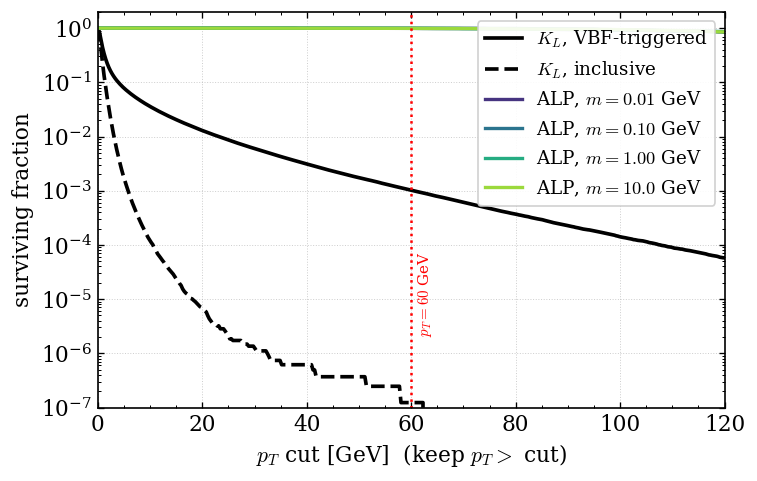

signal m=0.01: eff(pt>60) = 0.990
signal m=0.10: eff(pt>60) = 0.992
signal m=1.00: eff(pt>60) = 0.990
signal m=10.0: eff(pt>60) = 0.989
K_L VBF-triggered: eff(pt>60) = 1.02e-03
K_L inclusive: eff(pt>60) = 1.23e-07


In [43]:
import matplotlib.pyplot as plt, numpy as np

def eff(pt, cuts):                       # fraction with pt > cut
    s = np.sort(np.asarray(pt))
    return (len(s) - np.searchsorted(s, cuts, side="right")) / len(s)

cuts = np.linspace(0, 120, 400)
# ---------- global publication style (same as before) ----------
plt.rcParams.update({
    "font.size": 13,
    "font.family": "serif",
    "mathtext.fontset": "cm",
    "axes.linewidth": 1.0,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.top": True,
    "ytick.right": True,
    "xtick.minor.visible": True,
    "ytick.minor.visible": True,
    "figure.dpi": 120,
    "savefig.dpi": 300,
    "savefig.bbox": "tight",
})

fig, ax = plt.subplots(figsize=(6.5, 4.2))

# --- backgrounds ---
ax.plot(cuts, eff(hard_kl_sample_pt, cuts), lw=2.2, color="black",
        label=r"$K_L$, VBF-triggered")
ax.plot(cuts, eff(soft_kl_sample_pt, cuts), lw=2.2, color="black", ls="--",
        label=r"$K_L$, inclusive")

# --- signal (VBF-selected), one line per mass ---
sig = [(alp_pt_0p01_vbf,  r"ALP, $m=0.01$ GeV"),
       (alp_pt_0p10_vbf,  r"ALP, $m=0.10$ GeV"),
       (alp_pt_1p00_vbf,  r"ALP, $m=1.00$ GeV"),
       (alp_pt_10p00_vbf, r"ALP, $m=10.0$ GeV")]
colors = plt.cm.viridis(np.linspace(0.15, 0.85, len(sig)))
for (pt, lbl), c in zip(sig, colors):
    ax.plot(cuts, eff(pt, cuts), lw=2.0, color=c, label=lbl)

ax.axvline(60, color="red", ls=":", lw=1.5)
ax.text(61, 2e-6, r"$p_T = 60$ GeV", color="red", rotation=90, va="bottom", fontsize=9)

ax.set_yscale("log")
ax.set_xlabel(r"$p_T$ cut [GeV]  (keep $p_T >$ cut)")
ax.set_ylabel(r"surviving fraction")
ax.set_xlim(0, 120); ax.set_ylim(1e-7, 2)
ax.grid(True, which="major", ls=":", lw=0.6, alpha=0.6)
ax.legend(fontsize=11, frameon=True, framealpha=0.9, loc="upper right")
fig.tight_layout()
fig.savefig("/home/export/sdurgut/scratch/alps/bkg/FORESEE/alp/plots/pt_cut_efficiency_2.png", dpi=300)
plt.show()

# --- the exact numbers in the claim ---
for name, pt in [("signal (avg over masses)", None),
                 ("K_L VBF-triggered", hard_kl_sample_pt),
                 ("K_L inclusive",      soft_kl_sample_pt)]:
    if pt is None:
        for lbl, arr in zip(["0.01","0.10","1.00","10.0"],
                            [alp_pt_0p01_vbf, alp_pt_0p10_vbf, alp_pt_1p00_vbf, alp_pt_10p00_vbf]):
            print(f"signal m={lbl}: eff(pt>60) = {np.mean(np.asarray(arr)>60):.3f}")
    else:
        print(f"{name}: eff(pt>60) = {np.mean(np.asarray(pt)>60):.2e}")